In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import (
    BatHeadDirectionSystem,
    sphere_to_toroid,
    BatHDSystemConfig,
)
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor

DATA_DIR = "../simulation_data/comparison"
PLOTS_DIR = "../plots/comparison"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
T = 400
dt = 0.5e-3
n = (256, 128)
intrinsic_noise = 0
input_noise = 0
n_conj = (20, 10)
n_landmarks = 40
interval = 100
rng = np.random.default_rng(seed=0)


def split_flight_data(bat_flight, split_time):
    split_index = np.searchsorted(bat_flight["time"], split_time)
    bat_flight_1 = {key: value[:split_index] for key, value in bat_flight.items()}
    bat_flight_2 = {key: value[split_index:] for key, value in bat_flight.items()}
    return bat_flight_1, bat_flight_2


low_noise_bat_flight, bat_flight = split_flight_data(
    generate_bat_flight(T=T, dt=dt), split_time=T / 8
)


no_anchor_config = BatHDSystemConfig(
    dt=dt,
    n_ring=n,
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=(2, 2),
    ring_conj_projection_strength=0,
    ring_input_strength=0,
    feedback_mode="none",
)

conj_grid_config = BatHDSystemConfig(
    dt=dt,
    n_ring=n,
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    n_landmark=n_landmarks,
    conj_feedback_strength=1,
    conj_gain=2.5,
    ring_input_strength=(0.5, 0.2),
    vision_gated=True,
    feedback_mode="conjunctive_grid",
)

visual_field_config = BatHDSystemConfig(
    dt=dt,
    n_ring=n,
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    conj_feedback_strength=1,
    ring_input_strength=(0.4, 0.2),
    ring_conj_projection_strength=(1, 0.5),
    vision_gated=True,
    visual_drive=1,
    conj_gain=1.5,
    inhibition=1,
    feedback_mode="visual_field",
    learn_weights=False,
)

direct_feedback_config = BatHDSystemConfig(
    dt=dt,
    n_ring=n,
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    n_landmark=n_landmarks,
    ring_input_strength=(0.5, 0.5),
    vision_gated=True,
    feedback_mode="direct",
)


nets = {
    "no_anchor": BatHeadDirectionSystem(no_anchor_config),
    "conj_grid": BatHeadDirectionSystem(conj_grid_config),
    "visual_field": BatHeadDirectionSystem(visual_field_config),
    "direct_feedback": BatHeadDirectionSystem(direct_feedback_config),
}

for net in nets.values():
    net.warm_up()


with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {
        name: executor.submit(
            net.run_simulation,
            low_noise_bat_flight["dir_vel"],
            low_noise_bat_flight["dir_sphere"],
            interval=interval,
            save_weights=True,
            verbose=False,
        )
        for name, net in nets.items()
    }
    results_low_noise = {name: future.result() for name, future in futures.items()}

100%|██████████| 799999/799999 [00:55<00:00, 14308.25it/s]


Ran warm up for 202 steps
Ran warm up for 202 steps
Ran warm up for 202 steps
Ran warm up for 202 steps


In [3]:
intrinsic_noise = 0.01
input_noise = 2
interval = 1000
for net in nets.values():
    net.set_noise(input_noise=input_noise, intrinsic_noise=intrinsic_noise)
    # net.learn_weights = False

with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {
        name: executor.submit(
            net.run_simulation,
            bat_flight["dir_vel"],
            bat_flight["dir_sphere"],
            interval=interval,
            save_weights=True,
            verbose=True if name == "conjunctive_grid" else False,
        )
        for name, net in nets.items()
    }
    results = {name: future.result() for name, future in futures.items()}

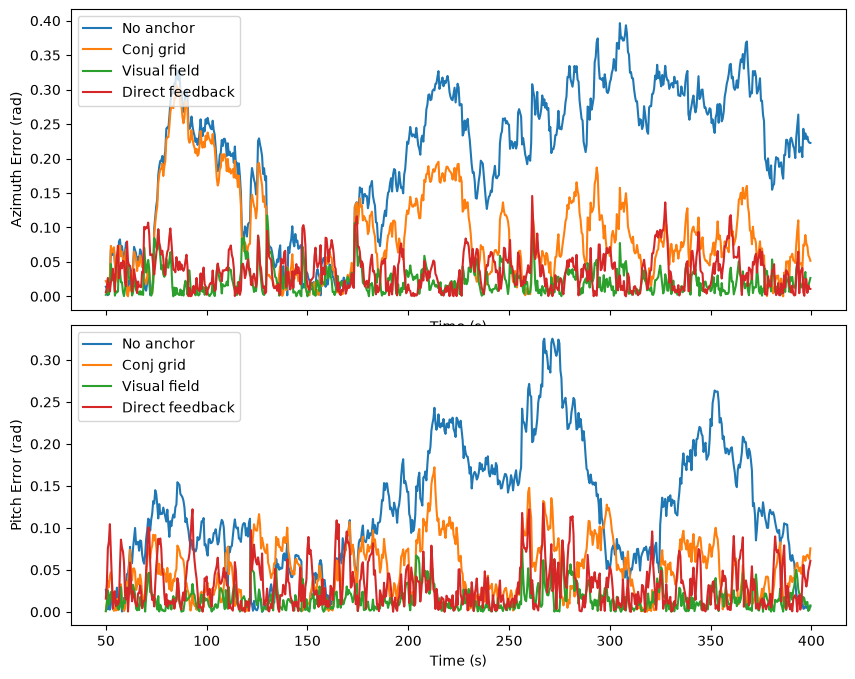

In [4]:
smooth_interval = 1

fig, ax = plt.subplots(
    nrows=2,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"hspace": (0.05)},
)
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    for name, recording in results.items():
        ax[angle_iter].plot(
            bat_flight["time"][:: interval * smooth_interval],
            np.abs(
                smooth_ts(
                    angular_error(
                        recording["decoded_angle"][:, angle_iter],
                        bat_flight["dir_sphere"][::interval, angle_iter],
                    ),
                    smooth_interval,
                )
            ),
            label=name.replace("_", " ").capitalize(),
        )
    ax[angle_iter].set_ylabel(f"{angle} Error (rad)")
    ax[angle_iter].set_xlabel("Time (s)")
    ax[angle_iter].legend()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_compare_mechanism.svg"))

In [5]:
results["conj_grid"]["conj_feedback_w"][0].sum(axis=(0, 1))

array([0.41634427, 0.49735579, 0.43130462, 0.4377393 , 0.41938715,
       0.54849632, 0.42213254, 0.50292248, 0.43088254, 0.67717017,
       0.48543318, 0.45259949, 0.42429549, 0.43923454, 0.53691467,
       0.56535441, 0.59557662, 0.43812865, 0.60652368, 0.4458248 ,
       0.43528819, 0.40210435, 0.80810749, 0.50308407, 0.41714969,
       0.51801306, 0.53585969, 0.44877672, 0.43150359, 0.53823378,
       0.46216884, 0.81164358, 0.46910309, 0.47048361, 0.58241525,
       0.42466008, 0.45508076, 0.54396375, 0.52872897, 0.44001071])